In [1]:
from anndata import AnnData
from scipy.stats import pearsonr, spearmanr, wilcoxon

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import squidpy as sq

import warnings 
warnings.filterwarnings('ignore') 

import sys
sys.path.append("../")
import auxiliary_lymphnode as auxln
import auxiliary_plot as auxpl
figsize = auxpl.figsize
fontsize = auxpl.fontsize

## Loading ST dataset

In [2]:
# input of decoupleR
adata_raw = sc.read_h5ad("results_lymphnode/lymphnode.h5ad")
# output of decoupleR
adata_coup = sc.read_h5ad("results_lymphnode/lymphnode_decoupler.h5ad")

In [3]:
adata_tfa = AnnData(
    X = adata_coup.obsm['ulm_estimate'],
    obs = adata_coup.obs,
    obsm = {name: obj for (name, obj) in adata_coup.obsm.items() if "tf" not in name},
    layers = {name: obj for (name, obj) in adata_coup.obsm.items() if "tf" in name})
adata_tfa.uns = adata_coup.uns

For mRNA expression, normalize each spot by total counts over all genes

In [4]:
sc.pp.normalize_total(adata_raw)
adata_raw.layers['scaled'] = np.sqrt(adata_raw.to_df())

sc.pp.normalize_total(adata_coup)
adata_coup.layers['scaled'] = np.sqrt(adata_coup.to_df())

## Visualizing TFa in spatial coordinates
We rank TFs and genes for germinal centers and nongerminal centers.

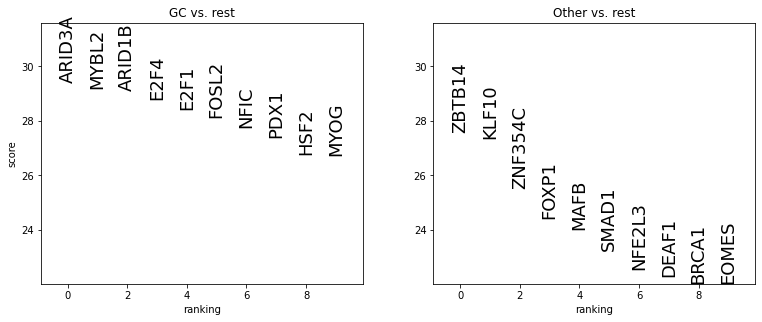

In [5]:
adata_tfa.obs['germinal_center'] = adata_tfa.obs['germinal_center'].astype('category')
sc.tl.rank_genes_groups(adata_tfa, groupby='germinal_center', method="wilcoxon")
sc.pl.rank_genes_groups(adata_tfa, fontsize=fontsize, n_genes=10)

## Celltype Proportion and TF Activity

In [6]:
df_celltype = auxln.merge_celltypes(adata_raw)
adata_raw.obsm['celltype_major'] = df_celltype
adata_coup.obsm['celltype_major'] = df_celltype
adata_tfa.obsm['celltype_major'] = df_celltype  

In [7]:
def plot_spatial_ct_tf(ct, tf):
    fig, axs = plt.subplots(1,3, figsize=(figsize*3,figsize), dpi=100)
    sc.pl.spatial(sq.pl.extract(adata_tfa, "celltype_major"),
                  color=ct, alpha_img=0, ax=axs[0], show=False, cmap="rocket", size=1.8,
                  legend_fontsize=fontsize)
    sc.pl.spatial(adata_tfa, color=tf, alpha_img=0, ax=axs[1],show=False, cmap="plasma", 
                  legend_fontsize=fontsize, size=1.8)
    sc.pl.spatial(adata_raw, color=tf, alpha_img=0, ax=axs[2],show=False, cmap="viridis", 
                  legend_fontsize=fontsize, size=1.8)

    axs[0].set_title(ct+'\n', fontsize=fontsize)
    axs[1].set_title(tf+' activity\npearson=%.4f'% mat_cor_tfa.loc[tf, ct], fontsize=fontsize)
    axs[2].set_title(tf+" mRNA expr\npearson=%.4f"% mat_cor_rna.loc[tf, ct], fontsize=fontsize)
    for i in range(3):
        axs[i].set_xlabel("")
        axs[i].set_ylabel("")
    plt.tight_layout(pad=0.6)

In [8]:
mat_cor_tfa, mat_cor_rna = auxpl.make_cor_dataframe(adata_raw, adata_tfa, celltype_label='celltype_major')

In [9]:
df_ct_tf = auxpl.make_ct_tf_dataframe(adata_tfa, celltype_label='celltype_major')

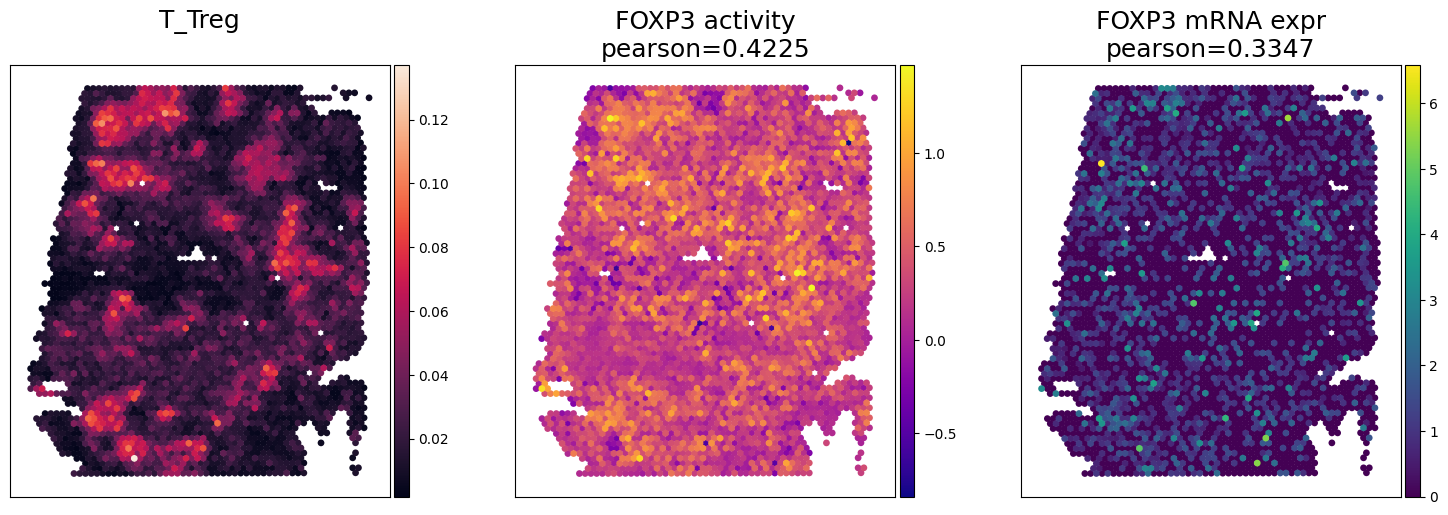

In [10]:
plot_spatial_ct_tf(ct = "T_Treg", tf = "FOXP3")

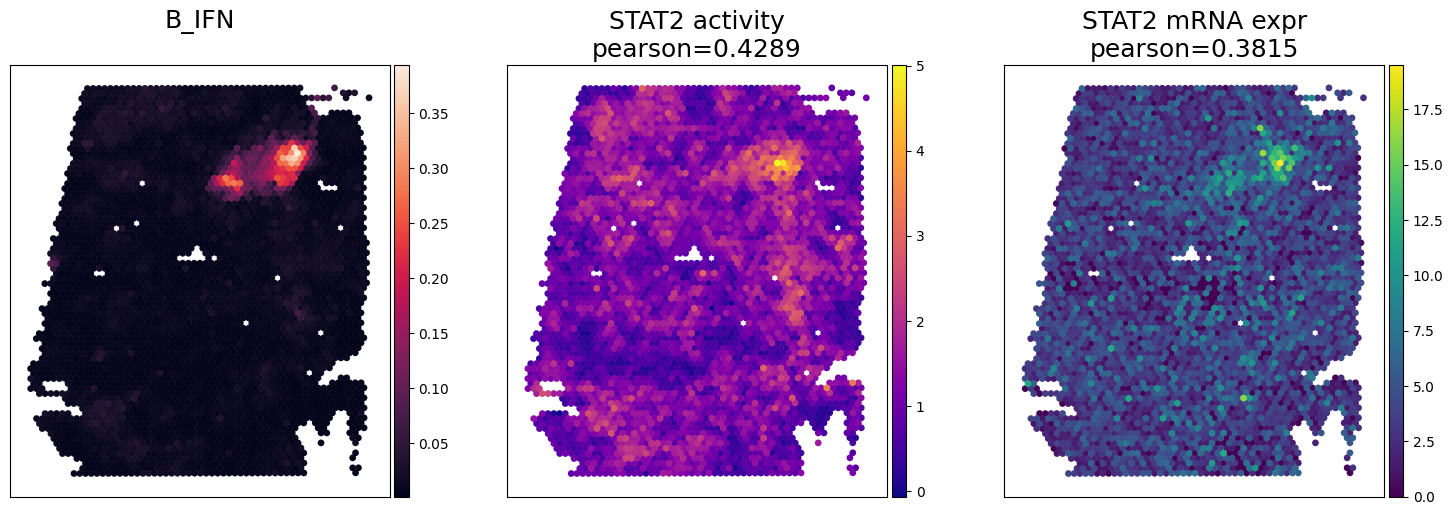

In [11]:
plot_spatial_ct_tf(ct = "B_IFN", tf = "STAT2")

In [12]:
df_ct_tf = auxpl.make_ct_tf_dataframe(adata_tfa, celltype_label='celltype_major')
tf_list = ['BACH2', 'BCL11A', 'CDX2', 'CREB1', 'E2F1', 'E2F7', 'EBF1', 'ETS1', 'ETV6',
 'FOXM1', 'FOXP2', 'FOXP3', 'GTF2B', 'IRF1', 'IRF2', 'KLF1', 'KMT2A', 'MAX', 'MYB',
 'NR5A2', 'PAX5', 'PBX1', 'PGR', 'POU2F2', 'PPARG', 'RFX3', 'SPIB', 'STAT1',
 'STAT2', 'STAT3', 'STAT4', 'STAT5B', 'TBX21', 'TCF21']
ct_list = ['B_Cycling', 'B_GC', 'T_TIM3+', 'B_preGC', 'B_activated', 'NK', 'T_CD8+', 'NKT',
 'VSMC', 'FDC', 'T_TfR', 'T_Treg', 'B_mem', 'B_plasma', 'Monocytes', 'B_IFN', 'DC',
 'ILC', 'Macrophages', 'T_CD4+']

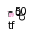

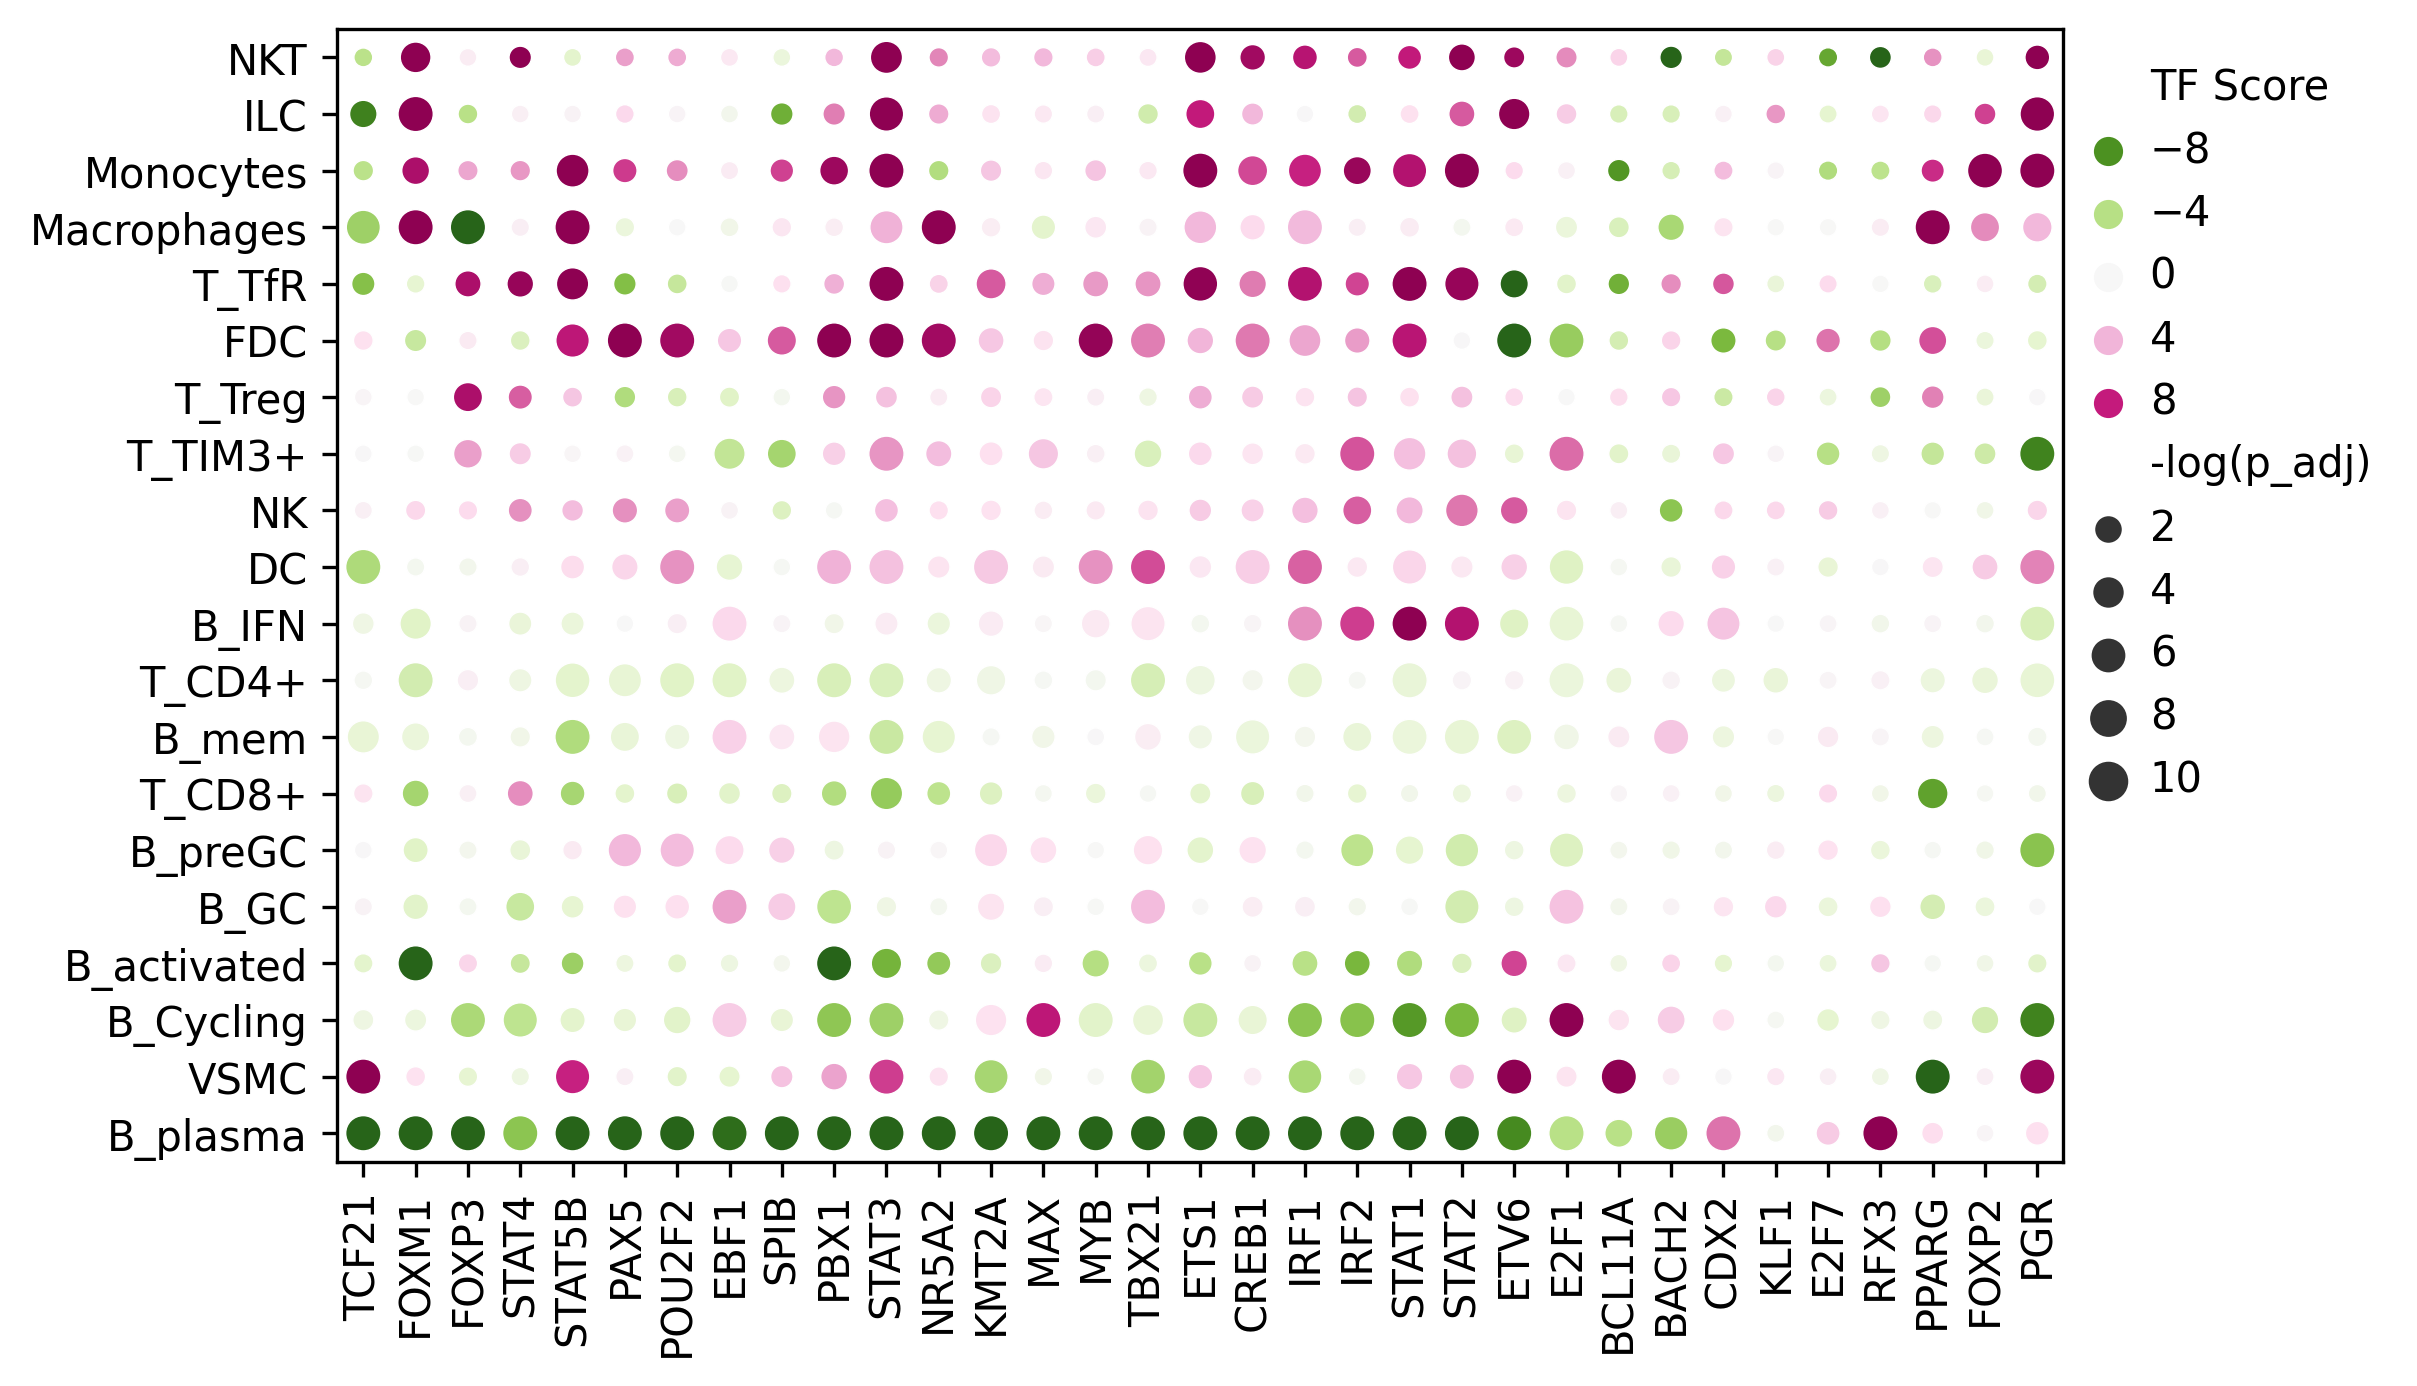

In [13]:
auxpl.plot_heatmap(df_ct_tf, tf_list, ct_list)

## Additional plots to be generated in R
Figure S2A and Figure S2B

In [14]:
!mkdir ../df2plot_inR/
df_ct_tf.query("tf in @tf_list and ct in @ct_list").to_csv('../df2plot_inR/lymphnode_tf_by_celltype_decoupler.csv')

mkdir: ../df2plot_inR/: File exists


In [15]:
dedf_tf = sc.get.rank_genes_groups_df(adata_tfa, group="GC")
dedf_tf.index = dedf_tf['names']
df_tfa = pd.DataFrame(index=dedf_tf['names'], columns = ['mean_gc', 'mean_other', 'diff', 'pvals_adj'])
df_tfa['pvals_adj'] = dedf_tf['pvals_adj']

adata_tfa_gc = adata_tfa[adata_tfa.obs['germinal_center']=='GC']
adata_tfa_other = adata_tfa[adata_tfa.obs['germinal_center']=='Other']
df_tfa['mean_gc'] = adata_tfa_gc.to_df().mean()
df_tfa['mean_other'] = adata_tfa_other.to_df().mean()
df_tfa['diff'] = df_tfa['mean_gc'] - df_tfa['mean_other']

df_tfa['diff'].sort_values()
df_tfa.to_csv('../df2plot_inR/lymphnode_dedf_tf_decoupler.csv')